In [9]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from stable_baselines3 import DQN
from env.trading_env import MyTradingEnv
from agents.train_dqn import DQNConfig


In [10]:
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2022.csv')

df_test.head()

,open,high,low,close,volume
0,46216.93,46731.39,46208.37,46656.13,1503.33095
1,46656.14,46949.99,46574.06,46778.14,943.81539
2,46778.14,46928.94,46721.96,46811.77,485.16860
3,46811.77,46916.63,46760.12,46813.20,562.88971
4,46813.21,46887.33,46591.23,46711.05,861.88389


In [11]:
RUN_ID = "20260331-113854-46af79"
run_dir = project_root / 'experiments' / 'dqn-test' / f"{RUN_ID}"
config_path = run_dir / 'config.json'
model_path = run_dir / 'model'

config = DQNConfig(**json.loads(config_path.read_text()))
config

window_size = 10
env_test = MyTradingEnv(df_test, window_size=window_size)
env_test.clear_history()

model = DQN.load(str(model_path), env=env_test)

obs, _ = env_test.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(int(action))
    done = terminated or truncated




Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [12]:
test_steps = env_test.get_steps_df()
test_trades = env_test.get_trades_df()

test_steps.head()


,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,7280,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,20487.76,0,None,0.0
1,1,2,7281,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,20714.01,0,None,0.0
2,1,3,7282,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,20750.56,0,None,0.0
3,1,4,7283,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,20730.54,0,None,0.0
4,1,5,7284,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,20698.27,0,None,0.0


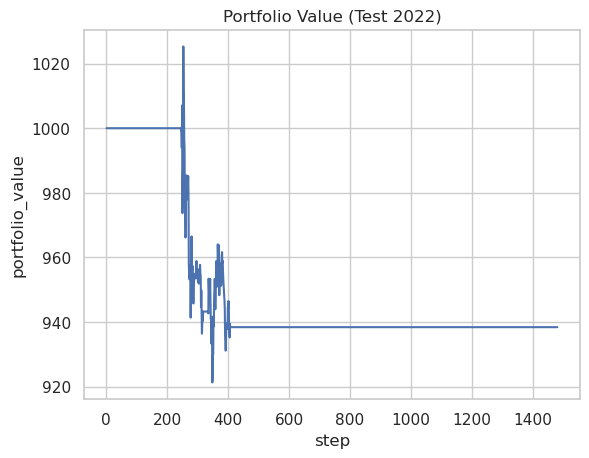

,entry_price,exit_price,pnl,units,holding_time,max_drawdown,exit_reason
0,17659.755465,16661.195235,-56.633079,0.056620,72,0.063488,time
1,16643.807745,16561.764975,-4.743058,0.056668,72,0.023168,time


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=test_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Test 2022)')
plt.show()

trades_df = test_trades
trades_df.head()
